# Characterizing Adversarial Queries

This notebook characterizes the adversarial queries generated by our Bayesian-optimization-based process.
It covers:
1. **Result sizes** — run each query (adversarial plan, `count(*)`) and plot the distribution.
2. **Descriptive characteristics** — tables, predicate columns, filter counts, etc.
3. **Plan shape analysis** — classify default and adversarial plans as left-deep, right-deep, zig-zag, or bushy; show distributions and pairwise transitions.

In [1]:
import ast
import json as _json
import os
import sys
import time
from collections import Counter, defaultdict
from itertools import combinations

sys.path.insert(0, '..')

import duckdb
import lark
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import networkx as nx
import numpy as np
import pandas as pd
import psycopg
from types import SimpleNamespace
from dataclasses import dataclass

from optimization.codec.codec import HashProbeStackMachineCodec, JoinTreeBranch, JoinTreeLeaf
from oracle.adversarial_queries import get_predicate_graph
from training.data.duckdb_jointree import build_join_tree
from workload.workloads import IMDB_WORKLOAD_SET

# ── DuckDB connection ────────────────────────────────────────────────────────
DB_PATH = '../workload/adversarial-benchmark/imdb.duckdb'
assert os.path.exists(DB_PATH), f'Database not found at {DB_PATH}'
con = duckdb.connect(DB_PATH)
con.execute("SET memory_limit = '32GB'")
print(f'Connected to {DB_PATH}')

# ── Codec / predicate graph ──────────────────────────────────────────────────
predicate_graph = get_predicate_graph(IMDB_WORKLOAD_SET)
all_tables = list(sorted(predicate_graph.nodes))
codec = HashProbeStackMachineCodec(all_tables)
print(f'Tables in codec: {len(all_tables)}')

Connected to ../workload/adversarial-benchmark/imdb.duckdb
Tables in codec: 21


In [2]:
# ── Postgres job-queue connection + bulk prefetch ────────────────────────────
# The job queue DB is remote (pg.rm.cab), so per-query round-trips are slow.
# We prefetch all predicate values and Steiner trees into memory up front.
with open('../oracle-config.json') as f:
    _cfg = _json.load(f)['job_queue']

pg_con = psycopg.connect(
    host=_cfg['host'], port=_cfg['port'],
    dbname=_cfg['database'], user=_cfg['user'], password=_cfg['password'],
    autocommit=True,
)
print(f"Connected to job queue Postgres ({_cfg['host']})")

# Bulk-load all predicate values into a dict
_predicate_cache = {}
with pg_con.cursor() as cur:
    cur.execute('SELECT schema, table_name, column_name, predicate_name, predicate_value FROM predicate_values')
    for row in cur.fetchall():
        _predicate_cache[(row[0], row[1], row[2], row[3])] = row[4]
print(f'  Cached {len(_predicate_cache):,} predicate values')

# Bulk-load all connected-tables (Steiner trees) into a dict
_connected_cache = {}
with pg_con.cursor() as cur:
    cur.execute('SELECT schema, input_tables, connected_tables FROM query_connected_tables')
    for row in cur.fetchall():
        key = (row[0], tuple(sorted(row[1])))
        _connected_cache[key] = row[2]
print(f'  Cached {len(_connected_cache):,} Steiner tree results')

pg_con.close()
print('  Postgres connection closed (all data in memory)')


def pg_get_predicate_value(table_name, column_name, predicate_name, schema='JOB'):
    key = (schema, table_name, column_name, predicate_name)
    if key not in _predicate_cache:
        raise KeyError(f'No predicate value for {key}')
    return _predicate_cache[key]


def pg_get_connected_tables(input_tables, schema='JOB'):
    key = (schema, tuple(sorted(input_tables)))
    if key not in _connected_cache:
        raise KeyError(f'No connected tables for {sorted(input_tables)}')
    return _connected_cache[key]


Connected to job queue Postgres


In [3]:
# ── DSL parsing helpers (mirrors gap_investigation.ipynb) ────────────────────
parsing_grammar = """
start: selector+
selector: "(" ident " " filter* ")"
?ident: /[a-z0-9_]+/
filter: int_filter | str_filter
int_filter: "(" ident " " intop " " intval ")"
str_filter: "(" ident " " strop ")"

!intop: "<" | ">" | "=" | "!="
!strop: "most_popular" | "random"

!intval: "first" | "median" | "last" | "mode" | /[0-9]{4}/
"""
g = lark.Lark(parsing_grammar)


def get_dsl_tables(query_dsl):
    t = g.parse(query_dsl)
    return [str(selector.children[0]) for selector in t.children]


def _build_where_parts(query_dsl, schema='JOB'):
    t = g.parse(query_dsl)
    where_clause = []
    tables_involved = []
    for selector in t.children:
        table_name = str(selector.children[0])
        tables_involved.append(table_name)
        for filt in selector.children[1:]:
            filt = filt.children[0]
            if filt.data == 'int_filter':
                field = str(filt.children[0])
                operator = str(filt.children[1].children[0])
                predicate_name = str(filt.children[2].children[0])
                rvalue = pg_get_predicate_value(table_name, field, predicate_name, schema)
                where_clause.append(f'{table_name}.{field} {operator} {rvalue}')
            elif filt.data == 'str_filter':
                field = str(filt.children[0])
                predicate_name = str(filt.children[1].children[0])
                rvalue = pg_get_predicate_value(table_name, field, predicate_name, schema)
                where_clause.append(f"{table_name}.{field} = '{rvalue}'")
    connected_tables = pg_get_connected_tables(tables_involved, schema)
    subgraph = predicate_graph.subgraph(connected_tables)
    for e in subgraph.edges:
        where_clause.append(subgraph.edges[e]['label'])
    return where_clause, connected_tables


def get_connected_tables(query_dsl, schema='JOB'):
    return pg_get_connected_tables(get_dsl_tables(query_dsl), schema)


def dsl_to_default_sql(query_dsl, schema='JOB'):
    where_clause, connected_tables = _build_where_parts(query_dsl, schema)
    return f"SELECT count(*)\nFROM {', '.join(connected_tables)}\nWHERE {'  AND '.join(where_clause)}"


def build_adversarial_sql(query_dsl, plan_vector_str, schema='JOB'):
    plan_vector = ast.literal_eval(plan_vector_str)
    tables = get_connected_tables(query_dsl, schema)
    tree = codec.decode([(t, 1) for t in tables], plan_vector)
    join_clause = tree.to_join_clause()
    where_clause, _ = _build_where_parts(query_dsl, schema)
    where_str = '\n  AND '.join(where_clause)
    return tree, join_clause, where_str


def classify_plan(tree):
    if tree.is_left_deep():
        return 'left-deep'
    if tree.is_right_deep():
        return 'right-deep'
    if tree.is_zigzag():
        return 'zig-zag'
    return 'bushy'


print('Helpers defined.')

Helpers defined.


In [4]:
# ── Load CSVs ────────────────────────────────────────────────────────────────
df_abs = pd.read_csv('imdb_adversarial_absolute.csv')
df_rel = pd.read_csv('imdb_adversarial_relative.csv')
print(f'Absolute dataset: {len(df_abs)} queries')
print(f'Relative dataset: {len(df_rel)} queries')


Absolute dataset: 999 queries
Relative dataset: 911 queries


---
## Part 1 — Result Sizes

We execute each query with the adversarial plan (`count(*)`) and record the
result size and wall-clock runtime in a local SQLite database
(`results_cache.db`).  The loop is **resumable**: queries that already have a
recorded result are skipped, so you can interrupt and restart freely.

Set `QUERY_TIMEOUT_S` to cap how long any single query may run.  Timed-out
queries are stored with `result_size = NULL` and `status = 'timeout'` so they
are not retried on the next run (change this by setting `RETRY_TIMEOUTS = True`).


In [5]:
import sqlite3
import threading

CACHE_DB = 'results_cache.db'
QUERY_TIMEOUT_S = 120   # seconds per query; set to None to disable
RETRY_TIMEOUTS  = True  # set True to re-run previously timed-out queries

# ── Initialise SQLite cache ──────────────────────────────────────────────────
cache_con = sqlite3.connect(CACHE_DB)
cache_con.execute('''
    CREATE TABLE IF NOT EXISTS query_results (
        dataset      TEXT NOT NULL,
        query        TEXT NOT NULL,
        generated_plan TEXT NOT NULL,
        result_size  INTEGER,          -- NULL if timed out or errored
        elapsed_ms   REAL,
        status       TEXT NOT NULL,    -- 'ok', 'timeout', 'error'
        PRIMARY KEY (dataset, query, generated_plan)
    )
''')
cache_con.commit()
print(f'Cache DB: {CACHE_DB}')

already = cache_con.execute('SELECT dataset, COUNT(*) FROM query_results GROUP BY dataset').fetchall()
for ds, n in already:
    print(f'  Already recorded: {n} {ds} queries')


def is_done(dataset, query, plan):
    row = cache_con.execute(
        'SELECT status FROM query_results WHERE dataset=? AND query=? AND generated_plan=?',
        (dataset, query, plan),
    ).fetchone()
    if row is None:
        return False
    if row[0] == 'timeout' and RETRY_TIMEOUTS:
        return False
    return True


def save_result(dataset, query, plan, result_size, elapsed_ms, status):
    cache_con.execute(
        '''INSERT INTO query_results (dataset, query, generated_plan, result_size, elapsed_ms, status)
           VALUES (?, ?, ?, ?, ?, ?)
           ON CONFLICT(dataset, query, generated_plan) DO UPDATE SET
               result_size=excluded.result_size,
               elapsed_ms=excluded.elapsed_ms,
               status=excluded.status''',
        (dataset, query, plan, result_size, elapsed_ms, status),
    )
    cache_con.commit()


def run_count_adversarial(query_dsl, plan_vector_str, schema='JOB'):
    """Execute adversarial plan as count(*) with optional timeout.
    Returns (row_count_or_None, elapsed_ms, status)."""
    try:
        _, join_clause, where_str = build_adversarial_sql(query_dsl, plan_vector_str, schema)
        sql = f'SELECT count(*)\nFROM {join_clause}\nWHERE {where_str}'
        con.execute("SET disabled_optimizers = 'join_order,build_side_probe_side'")
    except Exception as e:
        con.execute("SET disabled_optimizers = ''")
        return None, None, 'error'

    result = {}
    t0 = time.time()

    def _worker():
        try:
            result['count'] = con.execute(sql).fetchone()[0]
        except duckdb.InterruptException:
            result['timed_out'] = True
        except Exception as e:
            result['error'] = str(e)

    t = threading.Thread(target=_worker, daemon=True)
    t.start()
    t.join(timeout=QUERY_TIMEOUT_S)
    elapsed_ms = (time.time() - t0) * 1000

    if t.is_alive():
        con.interrupt()
        t.join()
        con.execute("SET disabled_optimizers = ''")
        return None, elapsed_ms, 'timeout'

    con.execute("SET disabled_optimizers = ''")

    if 'count' in result:
        return result['count'], elapsed_ms, 'ok'
    return None, elapsed_ms, 'error'


def run_all(df, dataset_label):
    n_skip = n_ok = n_timeout = n_error = 0
    total = len(df)
    print(f'\n{dataset_label}: {total} queries  (timeout={QUERY_TIMEOUT_S}s, retry_timeouts={RETRY_TIMEOUTS})')
    for pos, (_, row) in enumerate(df.iterrows()):
        q, plan = row['query'], row['generated_plan']
        if is_done(dataset_label, q, plan):
            n_skip += 1
            continue
        cnt, elapsed_ms, status = run_count_adversarial(q, plan)
        save_result(dataset_label, q, plan, cnt, elapsed_ms, status)
        if status == 'ok':
            n_ok += 1
            print(f'  [{pos+1}/{total}] {cnt:,} rows  ({elapsed_ms:.0f} ms)')
        elif status == 'timeout':
            n_timeout += 1
            print(f'  [{pos+1}/{total}] TIMEOUT  ({elapsed_ms:.0f} ms)')
        else:
            n_error += 1
            print(f'  [{pos+1}/{total}] ERROR')
    print(f'  done: skipped={n_skip}, ok={n_ok}, timeout={n_timeout}, error={n_error}')


run_all(df_abs, 'absolute')
run_all(df_rel, 'relative')


Cache DB: results_cache.db
  Already recorded: 999 absolute queries
  Already recorded: 911 relative queries

absolute: 999 queries  (timeout=120s, retry_timeouts=True)
  [2/999] 0 rows  (96973 ms)
  [4/999] TIMEOUT  (120000 ms)
  [5/999] TIMEOUT  (120000 ms)
  [6/999] TIMEOUT  (120000 ms)
  [7/999] TIMEOUT  (120000 ms)
  [8/999] TIMEOUT  (120000 ms)
  [9/999] TIMEOUT  (120000 ms)
  [10/999] TIMEOUT  (120000 ms)
  [14/999] TIMEOUT  (120000 ms)
  [15/999] TIMEOUT  (120000 ms)
  [16/999] TIMEOUT  (120000 ms)
  [17/999] TIMEOUT  (120000 ms)
  [19/999] TIMEOUT  (120000 ms)
  [21/999] 0 rows  (78460 ms)
  [23/999] TIMEOUT  (120000 ms)
  [46/999] TIMEOUT  (120000 ms)
  [55/999] 0 rows  (44973 ms)
  [56/999] TIMEOUT  (120000 ms)
  [60/999] TIMEOUT  (120001 ms)
  [61/999] 3,038,011,088 rows  (55584 ms)
  [62/999] 6,585,290,712 rows  (66945 ms)
  [66/999] 15,169,741,149 rows  (63594 ms)
  [67/999] 11,042,924,592 rows  (79772 ms)
  [70/999] 29,307,374,563 rows  (37883 ms)
  [71/999] 17,575,757,3

KeyboardInterrupt: 

absolute: 836/999 queries with result sizes
relative: 820/911 queries with result sizes


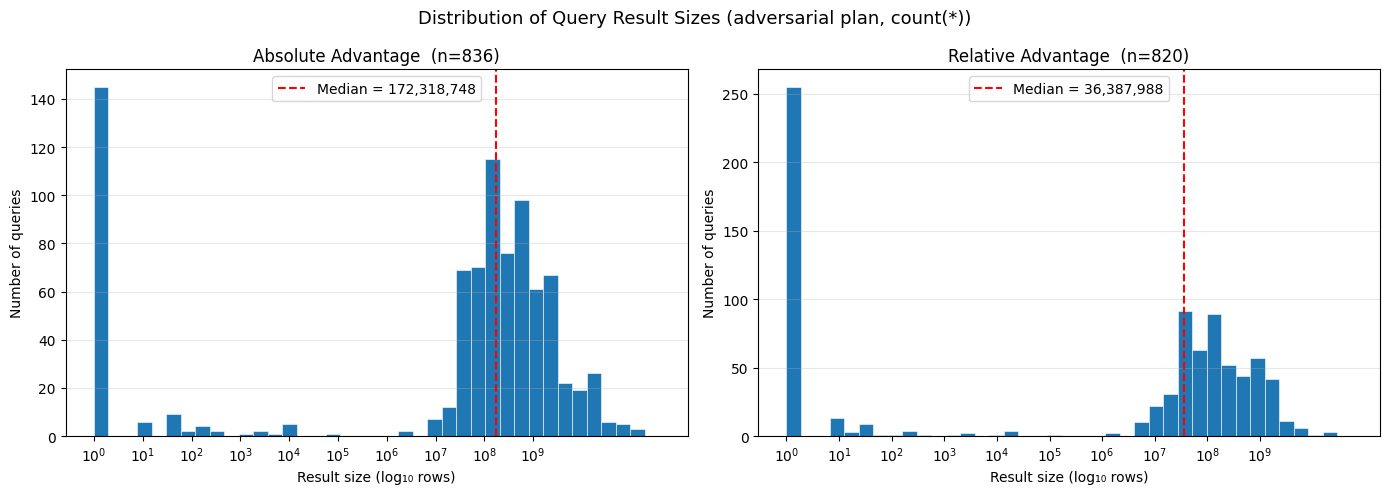

Absolute: min=0  median=172,318,748  mean=2,356,040,931  max=121,423,408,277
Relative: min=0  median=36,387,988  mean=376,059,089  max=17,534,311,016


In [6]:
# ── Load results from cache for plotting ─────────────────────────────────────
def load_results(df, dataset_label):
    rows = cache_con.execute(
        "SELECT query, generated_plan, result_size, elapsed_ms, status "        "FROM query_results WHERE dataset=?",
        (dataset_label,),
    ).fetchall()
    cache_df = pd.DataFrame(rows, columns=['query', 'generated_plan', 'result_size', 'elapsed_ms', 'status'])
    merged = df.merge(cache_df, on=['query', 'generated_plan'], how='left')
    ok = merged[merged['status'] == 'ok'].copy()
    print(f'{dataset_label}: {len(ok)}/{len(df)} queries with result sizes')
    return ok

res_abs = load_results(df_abs, 'absolute')
res_rel = load_results(df_rel, 'relative')

# ── Plot result-size distributions ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, res, label in [
    (axes[0], res_abs, 'Absolute Advantage'),
    (axes[1], res_rel, 'Relative Advantage'),
]:
    sizes = res['result_size'].dropna().astype(int)
    if len(sizes) == 0:
        ax.set_title(f'{label}  (no data yet)')
        continue
    sizes_log = np.log10(sizes.clip(lower=1))
    bins = np.linspace(0, sizes_log.max() + 0.5, 40)
    ax.hist(sizes_log, bins=bins, edgecolor='white', linewidth=0.4)
    ax.set_xlabel('Result size (log\u2081\u2080 rows)')
    ax.set_ylabel('Number of queries')
    ax.set_title(f'{label}  (n={len(sizes):,})')
    ticks = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    ax.set_xticks([t for t in ticks if t <= sizes_log.max() + 0.5])
    ax.set_xticklabels([f'$10^{{{t}}}$' for t in ticks if t <= sizes_log.max() + 0.5])
    ax.grid(axis='y', alpha=0.3)
    med = sizes.median()
    ax.axvline(np.log10(max(med, 1)), color='red', linestyle='--', label=f'Median = {med:,.0f}')
    ax.legend()

plt.suptitle('Distribution of Query Result Sizes (adversarial plan, count(*))', fontsize=13)
plt.tight_layout()
plt.show()

for res, label in [(res_abs, 'Absolute'), (res_rel, 'Relative')]:
    sizes = res['result_size'].dropna().astype(int)
    if len(sizes):
        print(f'{label}: min={sizes.min():,}  median={sizes.median():,.0f}  '
              f'mean={sizes.mean():,.0f}  max={sizes.max():,}')


---
## Part 2 — Descriptive Characteristics

We characterize the adversarial queries structurally: how many tables they span, which tables appear most often, which predicate columns are used, and how many filter predicates each query contains.  We show results for both the absolute- and relative-advantage datasets side by side.

In [7]:
# ── Parse DSL into structured records ───────────────────────────────────────
def parse_query(query_dsl):
    """Return (tables, filter_predicates) for a DSL query string."""
    t = g.parse(query_dsl)
    tables = []
    predicates = []  # (table, column, op_or_strop, value_or_None)
    for selector in t.children:
        table_name = str(selector.children[0])
        tables.append(table_name)
        for filt in selector.children[1:]:
            filt = filt.children[0]
            if filt.data == 'int_filter':
                col = str(filt.children[0])
                op  = str(filt.children[1].children[0])
                val = str(filt.children[2].children[0])
                predicates.append((table_name, col, op, val))
            elif filt.data == 'str_filter':
                col = str(filt.children[0])
                strop = str(filt.children[1].children[0])
                predicates.append((table_name, col, strop, None))
    return tables, predicates


def parse_df(df):
    records = []
    for _, row in df.iterrows():
        try:
            tables, preds = parse_query(row['query'])
            records.append({
                'query': row['query'],
                'tables': tables,
                'n_tables': len(tables),
                'predicates': preds,
                'n_predicates': len(preds),
            })
        except Exception:
            pass
    return pd.DataFrame(records)


parsed_abs = parse_df(df_abs)
parsed_rel = parse_df(df_rel)
print(f'Parsed: abs={len(parsed_abs)}, rel={len(parsed_rel)}')

Parsed: abs=999, rel=911


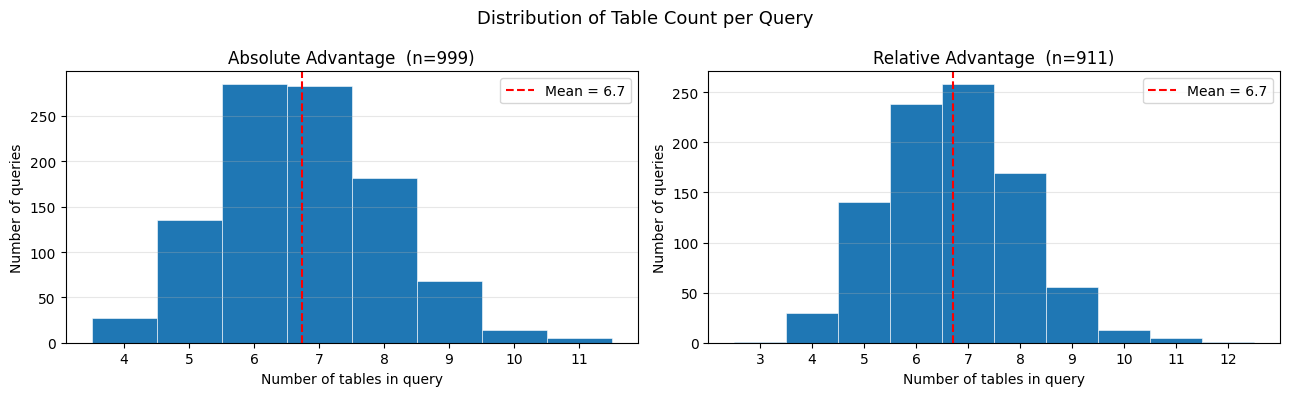

Absolute: min=4  max=11  mean=6.74  median=7  distribution={7: 283, 8: 182, 10: 14, 9: 68, 6: 285, 11: 5, 5: 135, 4: 27}
Relative: min=3  max=12  mean=6.71  median=7  distribution={7: 258, 8: 169, 10: 13, 9: 56, 11: 5, 6: 238, 5: 140, 4: 30, 12: 1, 3: 1}


In [8]:
# ── 2a. Table count distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, parsed, label in [
    (axes[0], parsed_abs, 'Absolute Advantage'),
    (axes[1], parsed_rel, 'Relative Advantage'),
]:
    counts = parsed['n_tables']
    bins = range(counts.min(), counts.max() + 2)
    ax.hist(counts, bins=bins, edgecolor='white', linewidth=0.4, align='left')
    ax.set_xlabel('Number of tables in query')
    ax.set_ylabel('Number of queries')
    ax.set_title(f'{label}  (n={len(counts):,})')
    ax.set_xticks(list(bins)[:-1])
    ax.grid(axis='y', alpha=0.3)
    ax.axvline(counts.mean(), color='red', linestyle='--', label=f'Mean = {counts.mean():.1f}')
    ax.legend()

plt.suptitle('Distribution of Table Count per Query', fontsize=13)
plt.tight_layout()
plt.show()

for parsed, label in [(parsed_abs, 'Absolute'), (parsed_rel, 'Relative')]:
    c = parsed['n_tables']
    print(f'{label}: min={c.min()}  max={c.max()}  mean={c.mean():.2f}  '
          f'median={c.median():.0f}  distribution={dict(Counter(c))}')

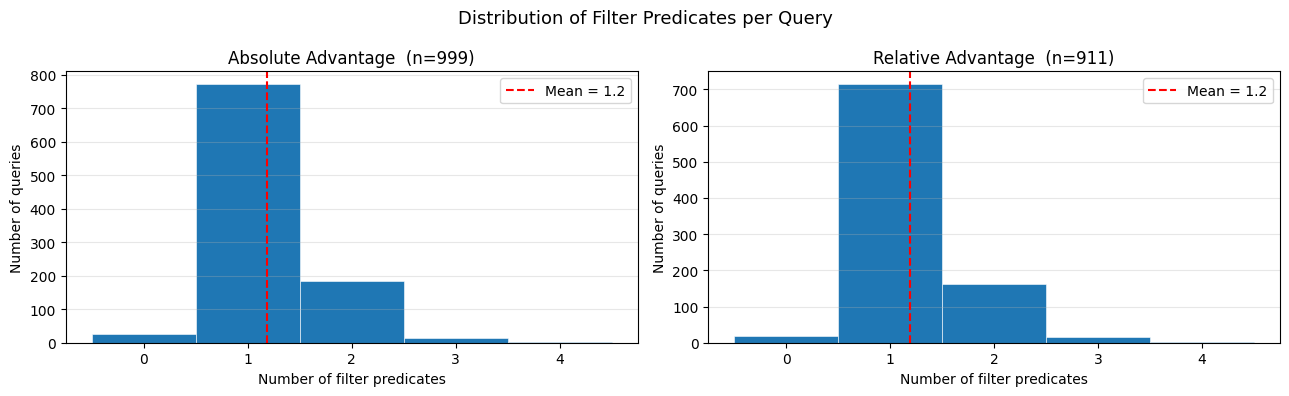

In [9]:
# ── 2b. Filter predicate count distribution ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, parsed, label in [
    (axes[0], parsed_abs, 'Absolute Advantage'),
    (axes[1], parsed_rel, 'Relative Advantage'),
]:
    counts = parsed['n_predicates']
    bins = range(counts.min(), counts.max() + 2)
    ax.hist(counts, bins=bins, edgecolor='white', linewidth=0.4, align='left')
    ax.set_xlabel('Number of filter predicates')
    ax.set_ylabel('Number of queries')
    ax.set_title(f'{label}  (n={len(counts):,})')
    ax.set_xticks(list(bins)[:-1])
    ax.grid(axis='y', alpha=0.3)
    ax.axvline(counts.mean(), color='red', linestyle='--', label=f'Mean = {counts.mean():.1f}')
    ax.legend()

plt.suptitle('Distribution of Filter Predicates per Query', fontsize=13)
plt.tight_layout()
plt.show()

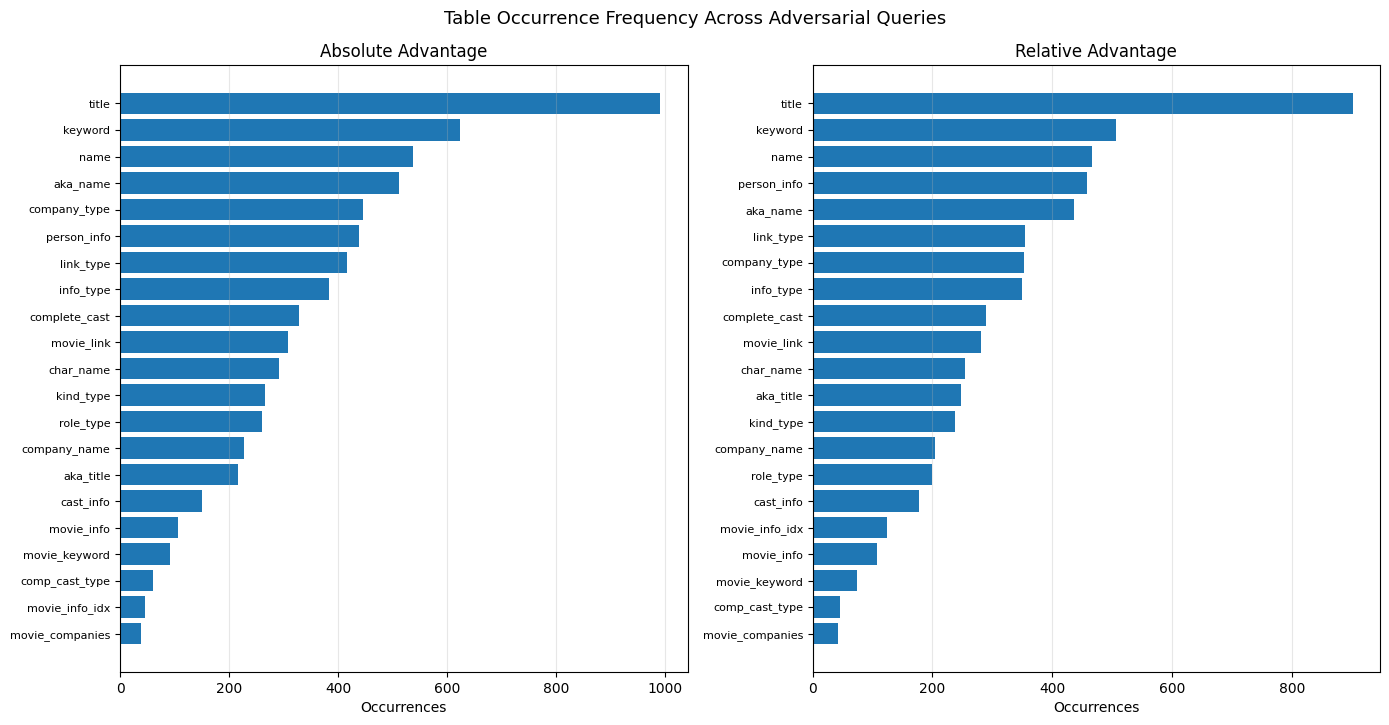

In [10]:
# ── 2c. Table occurrence frequencies ────────────────────────────────────────
def table_occurrences(parsed):
    ctr = Counter()
    for tables in parsed['tables']:
        ctr.update(tables)
    return ctr

occ_abs = table_occurrences(parsed_abs)
occ_rel = table_occurrences(parsed_rel)

# Use union of tables, sorted by max occurrence
all_t = sorted(set(occ_abs) | set(occ_rel),
               key=lambda t: max(occ_abs.get(t, 0), occ_rel.get(t, 0)), reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(all_t) * 0.35)))
for ax, occ, label in [(axes[0], occ_abs, 'Absolute'), (axes[1], occ_rel, 'Relative')]:
    sorted_occ = sorted(occ.items(), key=lambda x: x[1], reverse=True)
    tables_, counts_ = zip(*sorted_occ)
    ax.barh(range(len(tables_)), counts_)
    ax.set_yticks(range(len(tables_)))
    ax.set_yticklabels(tables_, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Occurrences')
    ax.set_title(f'{label} Advantage')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Table Occurrence Frequency Across Adversarial Queries', fontsize=13)
plt.tight_layout()
plt.show()

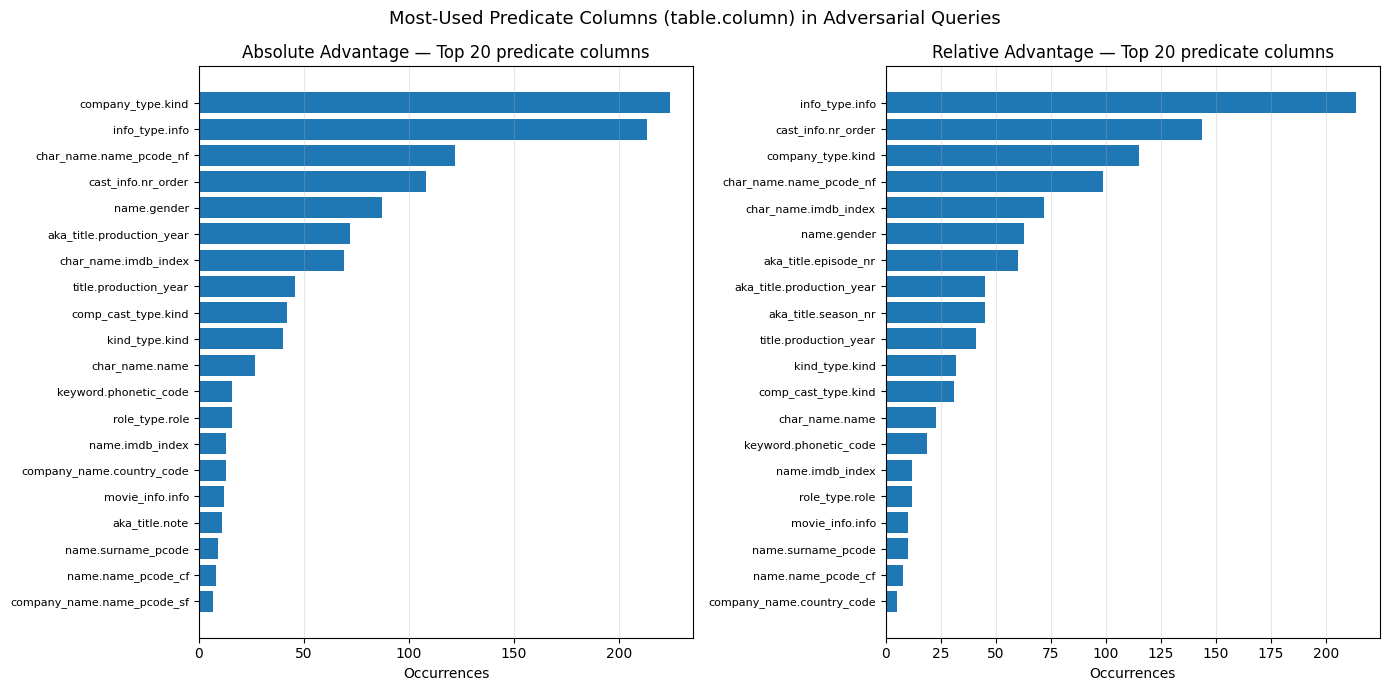

In [11]:
# ── 2d. Predicate column frequency (table.column) ───────────────────────────
def predicate_col_occurrences(parsed):
    ctr = Counter()
    for preds in parsed['predicates']:
        for (tbl, col, *_) in preds:
            ctr[(tbl, col)] += 1
    return ctr

pred_abs = predicate_col_occurrences(parsed_abs)
pred_rel = predicate_col_occurrences(parsed_rel)

TOP_N = 20
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, pred, label in [(axes[0], pred_abs, 'Absolute'), (axes[1], pred_rel, 'Relative')]:
    top = pred.most_common(TOP_N)
    labels_ = [f'{t}.{c}' for (t, c), _ in top]
    counts_ = [cnt for _, cnt in top]
    ax.barh(range(len(labels_)), counts_)
    ax.set_yticks(range(len(labels_)))
    ax.set_yticklabels(labels_, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Occurrences')
    ax.set_title(f'{label} Advantage — Top {TOP_N} predicate columns')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Most-Used Predicate Columns (table.column) in Adversarial Queries', fontsize=13)
plt.tight_layout()
plt.show()

---
## Part 3 — Plan Shape Analysis

We classify every default and adversarial plan as one of:
- **left-deep** — each right child is a leaf
- **right-deep** — each left child is a leaf
- **zig-zag** — alternates between left-deep and right-deep levels (but is neither purely left- nor right-deep)
- **bushy** — has internal nodes on both sides of at least one join

For single-table queries, all classifications trivially hold; those are filtered out.

In [12]:
@dataclass
class FakeWorkload:
    query_tables: list
    schema: object
    name: str = 'characterization'

fake_schema = SimpleNamespace(all_columns=IMDB_WORKLOAD_SET.all_columns)


def get_default_plan_tree(query_dsl, schema='JOB'):
    """Return the JoinTree for DuckDB's default plan, or None on failure."""
    try:
        where_clause, connected_tables = _build_where_parts(query_dsl, schema)
        default_sql = (
            f"SELECT count(*)\nFROM {', '.join(connected_tables)}\n"
            f"WHERE {'  AND '.join(where_clause)}"
        )
        explain_rows = con.execute(f'EXPLAIN (FORMAT JSON) {default_sql}').fetchall()
        plan_root = _json.loads(explain_rows[0][1])
        fake_wl = FakeWorkload(
            query_tables=[(t, 1) for t in sorted(connected_tables)],
            schema=fake_schema,
        )
        return build_join_tree(plan_root, fake_wl)
    except Exception as e:
        return None


def get_adversarial_plan_tree(query_dsl, plan_vector_str, schema='JOB'):
    """Return the JoinTree encoded in the adversarial plan vector."""
    try:
        plan_vector = ast.literal_eval(plan_vector_str)
        tables = get_connected_tables(query_dsl, schema)
        return codec.decode([(t, 1) for t in tables], plan_vector)
    except Exception:
        return None


print('Plan-tree helpers defined.')

Plan-tree helpers defined.


In [ ]:
# ── Collect plan shapes for both datasets ────────────────────────────────────
def collect_shapes(df, label):
    records = []
    for i, row in df.iterrows():
        if i % 100 == 0:
            print(f'  [{label}] {i}/{len(df)}')
        default_tree = get_default_plan_tree(row['query'])
        adv_tree = get_adversarial_plan_tree(row['query'], row['generated_plan'])
        if default_tree is None or adv_tree is None:
            continue
        # Skip trivial single-table cases
        if isinstance(default_tree, JoinTreeLeaf) or isinstance(adv_tree, JoinTreeLeaf):
            continue
        records.append({
            'default_shape': classify_plan(default_tree),
            'adv_shape': classify_plan(adv_tree),
        })
    return pd.DataFrame(records)


print('Collecting plan shapes for absolute-advantage queries…')
shapes_abs = collect_shapes(df_abs, 'abs')
print(f'  done: {len(shapes_abs)} rows')

print('Collecting plan shapes for relative-advantage queries…')
shapes_rel = collect_shapes(df_rel, 'rel')
print(f'  done: {len(shapes_rel)} rows')

  [abs] 0/999


In [ ]:
# ── 3a. Overall plan-shape distributions ────────────────────────────────────
SHAPE_ORDER = ['left-deep', 'right-deep', 'zig-zag', 'bushy']
COLORS = {'left-deep': '#4c72b0', 'right-deep': '#dd8452', 'zig-zag': '#55a868', 'bushy': '#c44e52'}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row_i, (shapes, ds_label) in enumerate([(shapes_abs, 'Absolute'), (shapes_rel, 'Relative')]):
    for col_i, (plan_col, plan_label) in enumerate([('default_shape', 'Default Plan'), ('adv_shape', 'Adversarial Plan')]):
        ax = axes[row_i][col_i]
        ctr = Counter(shapes[plan_col])
        vals = [ctr.get(s, 0) for s in SHAPE_ORDER]
        bars = ax.bar(SHAPE_ORDER, vals, color=[COLORS[s] for s in SHAPE_ORDER], edgecolor='white')
        ax.set_ylabel('Number of queries')
        ax.set_title(f'{ds_label} Advantage — {plan_label}  (n={len(shapes):,})')
        ax.grid(axis='y', alpha=0.3)
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                        str(val), ha='center', va='bottom', fontsize=9)

plt.suptitle('Plan Shape Distributions — Default vs. Adversarial', fontsize=13)
plt.tight_layout()
plt.show()

for shapes, label in [(shapes_abs, 'Absolute'), (shapes_rel, 'Relative')]:
    print(f'\n{label} Advantage:')
    print(f'  Default:     {dict(Counter(shapes["default_shape"]))}')
    print(f'  Adversarial: {dict(Counter(shapes["adv_shape"]))}')

In [ ]:
# ── 3b. Pairwise plan-shape transition heatmaps ──────────────────────────────
def plot_transition_heatmap(shapes, ax, title):
    """Heatmap: rows = default shape, cols = adversarial shape."""
    matrix = pd.crosstab(
        shapes['default_shape'], shapes['adv_shape'],
        rownames=['Default'], colnames=['Adversarial'],
    ).reindex(index=SHAPE_ORDER, columns=SHAPE_ORDER, fill_value=0)

    im = ax.imshow(matrix.values, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(SHAPE_ORDER)))
    ax.set_yticks(range(len(SHAPE_ORDER)))
    ax.set_xticklabels(SHAPE_ORDER, rotation=30, ha='right')
    ax.set_yticklabels(SHAPE_ORDER)
    ax.set_xlabel('Adversarial Plan Shape')
    ax.set_ylabel('Default Plan Shape')
    ax.set_title(title)

    for i in range(len(SHAPE_ORDER)):
        for j in range(len(SHAPE_ORDER)):
            val = matrix.values[i, j]
            if val > 0:
                ax.text(j, i, str(val), ha='center', va='center',
                        color='white' if val > matrix.values.max() * 0.6 else 'black',
                        fontsize=10, fontweight='bold')
    return im


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im0 = plot_transition_heatmap(shapes_abs, axes[0], 'Absolute Advantage')
im1 = plot_transition_heatmap(shapes_rel, axes[1], 'Relative Advantage')
plt.colorbar(im0, ax=axes[0], label='Query count')
plt.colorbar(im1, ax=axes[1], label='Query count')
plt.suptitle('Plan Shape Transitions: Default → Adversarial', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── 3c. Percentage-normalized transition tables ──────────────────────────────
for shapes, label in [(shapes_abs, 'Absolute'), (shapes_rel, 'Relative')]:
    matrix = pd.crosstab(
        shapes['default_shape'], shapes['adv_shape'],
        rownames=['Default \ Adversarial'], colnames=[''],
    ).reindex(index=SHAPE_ORDER, columns=SHAPE_ORDER, fill_value=0)
    pct = matrix.div(matrix.sum(axis=1), axis=0).mul(100).round(1)
    print(f'\n=== {label} Advantage: row-normalised transitions (%) ===')
    print(pct.to_string())